In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler
import pingouin as pg
import os
from tqdm import tqdm

warnings.filterwarnings('ignore')
# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


In [3]:
import pandas as pd

file = r"E:\pycharm all files\眼动数据处理\绘图\不归一化绘图\eeg整体2025.12.11.xlsx"
df = pd.read_excel(file, header=None)

records = []

current_indicator = None
current_electrode = None

for idx, row in df.iterrows():
    # 去掉空格
    first = str(row[0]).strip() if not pd.isna(row[0]) else ""

    # ---------- 指标行 ----------
    if first not in ["", "Fz", "Cz", "Pz", "Alcohol", "Placebo"] and pd.isna(row[1]):
        current_indicator = first
        continue

    # ---------- 电极行 ----------
    if first in ["Fz", "Cz", "Pz"]:
        current_electrode = first
        continue

    # ---------- 条件行 ----------
    if first in ["Alcohol", "Placebo"]:
        group = first
        stat_type = str(row[1]).strip()  # mean 或 se

        sessions = [f"s{i}" for i in range(1, 8)]

        for col, session in zip(range(2, 9), sessions):
            value = row[col]

            key = f"{current_indicator}_{current_electrode}"  # 只包含指标+电极

            records.append({
                "indicator_electrode": key,
                "group": group,
                "session": session,
                stat_type: value
            })

# 转 DataFrame
df_long = pd.DataFrame(records)

# 合并 mean 和 se
df_final = df_long.pivot_table(
    index=["indicator_electrode", "group", "session"],
    values=["mean", "se"],
    aggfunc="first"
).reset_index()

df_final


,indicator_electrode,group,session,mean,se
0,alpha_Cz,Alcohol,s1,0.419398,0.187815
1,alpha_Cz,Alcohol,s2,-0.000862,0.169125
2,alpha_Cz,Alcohol,s3,-0.041586,0.140069
3,alpha_Cz,Alcohol,s4,0.395096,0.134934
4,alpha_Cz,Alcohol,s5,0.253647,0.121446
...,...,...,...,...,...
163,theta_Pz,Placebo,s3,0.098246,0.088875
164,theta_Pz,Placebo,s4,0.114400,0.135276
165,theta_Pz,Placebo,s5,-0.256762,0.266826
166,theta_Pz,Placebo,s6,0.304791,0.253712


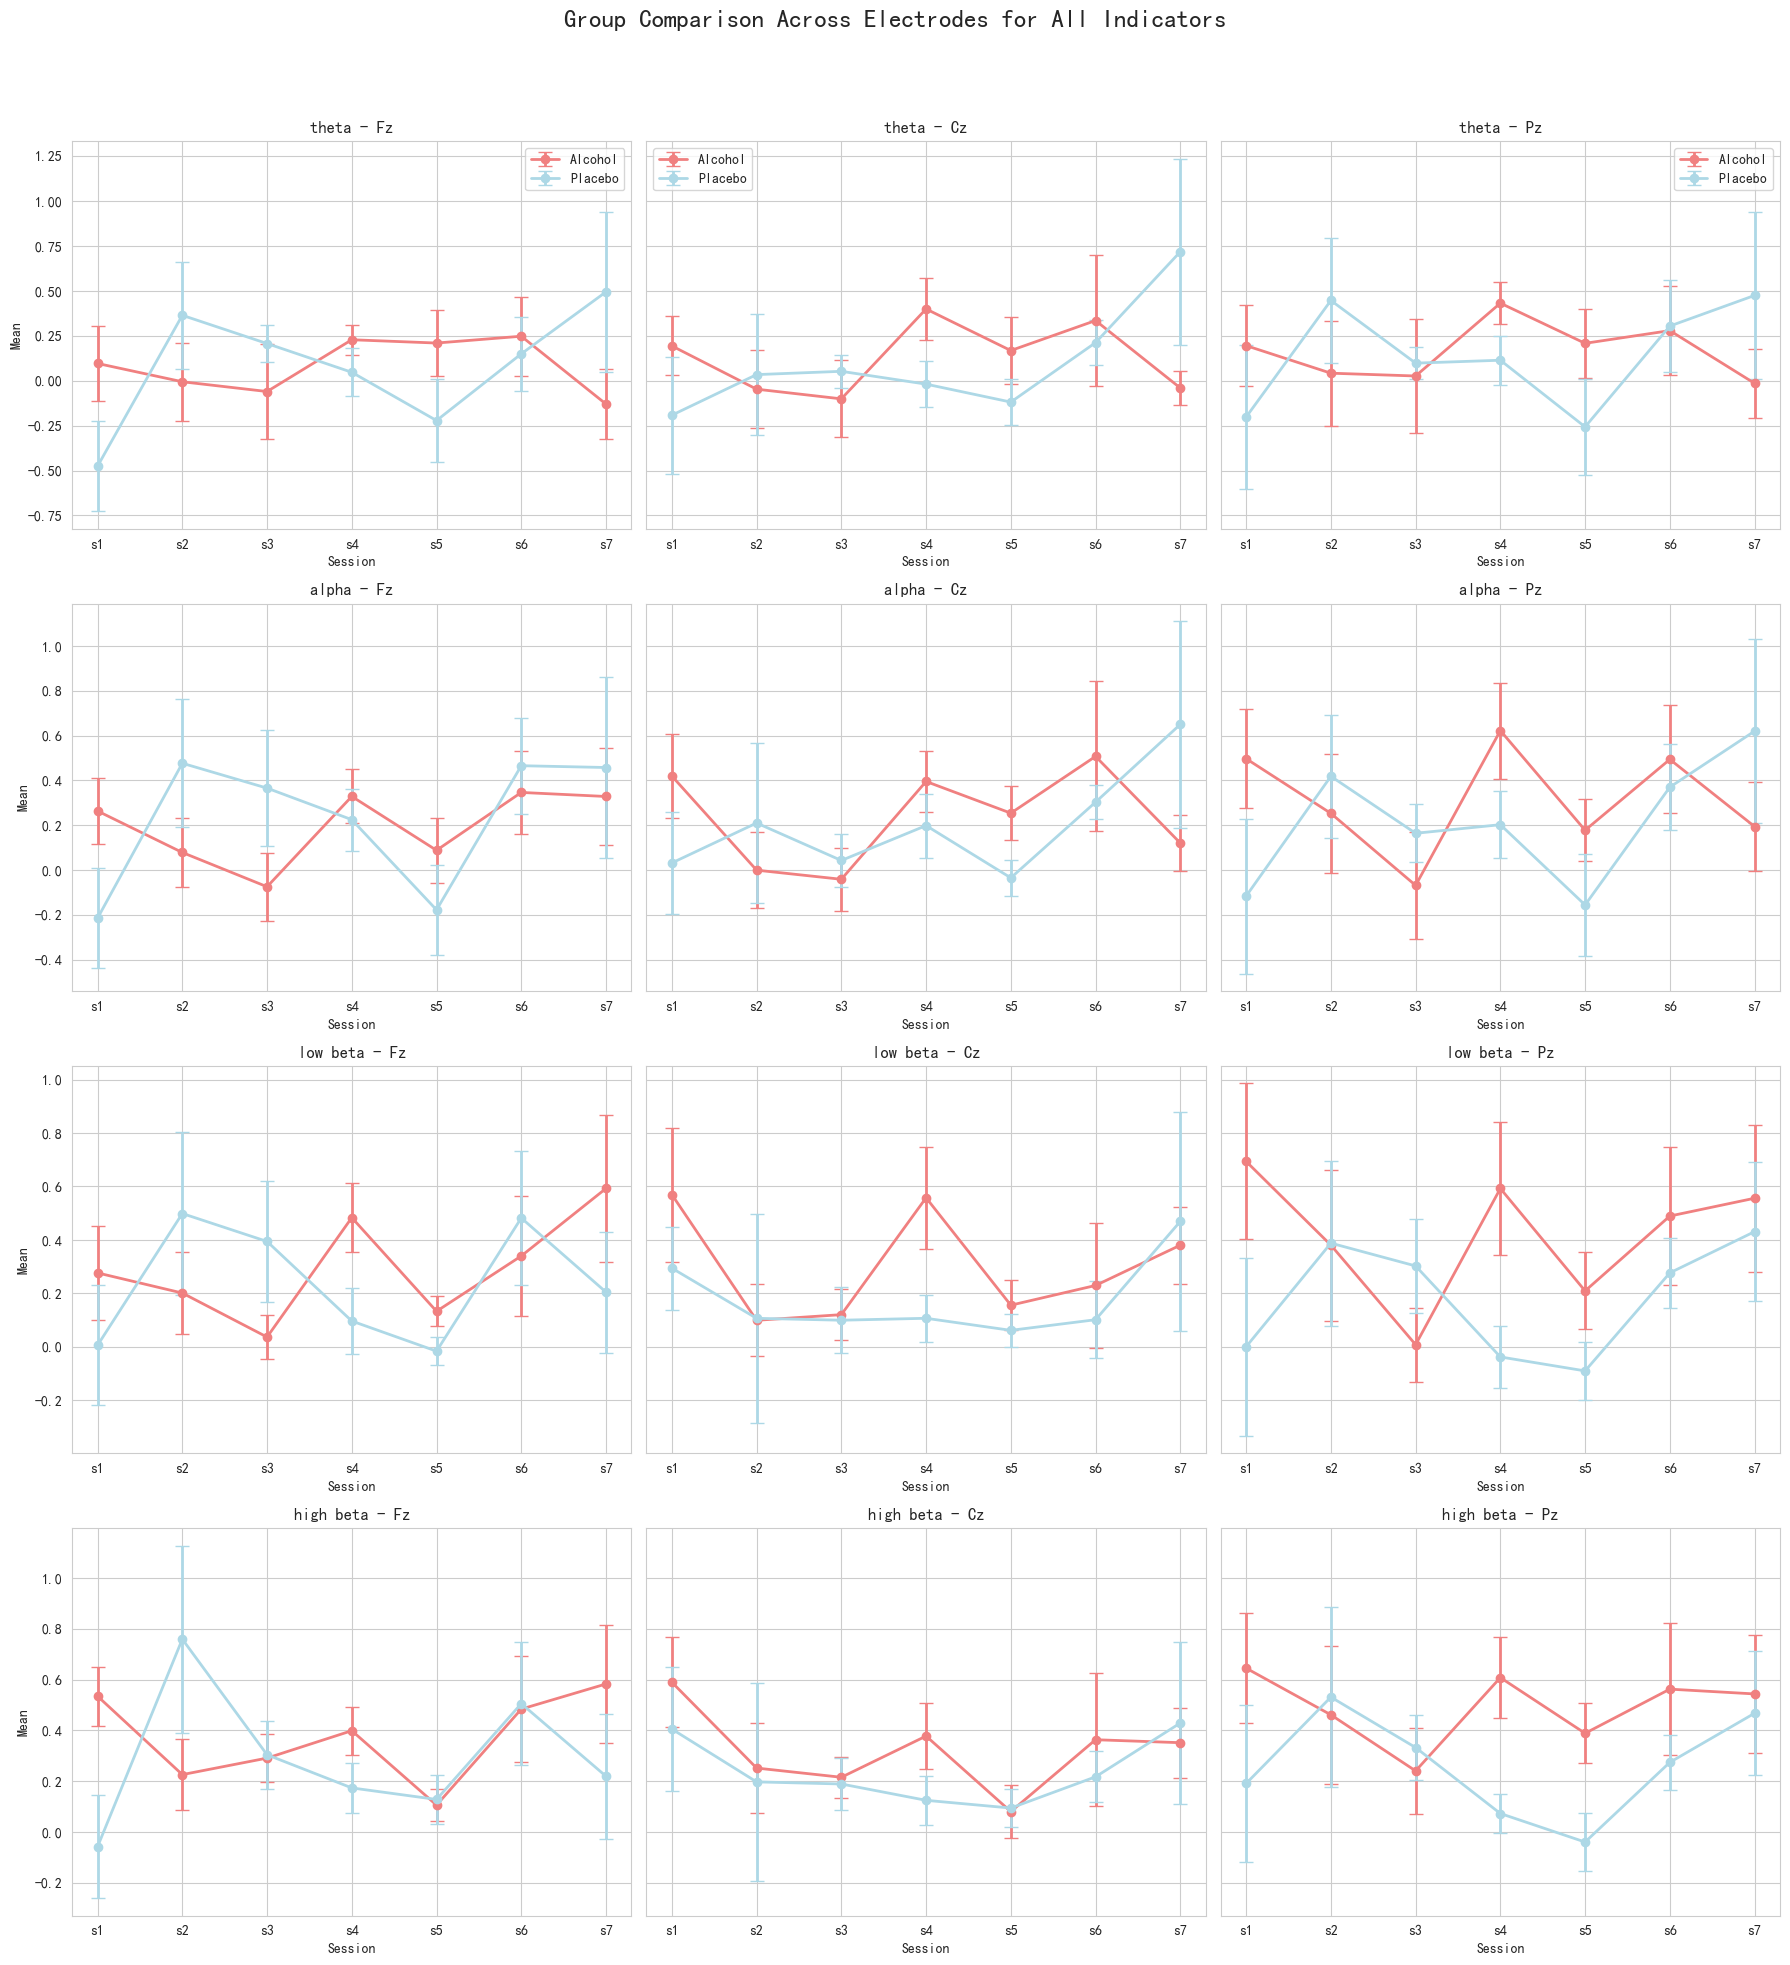

In [5]:
# 指定两组的颜色
group_colors = {"Alcohol": "lightcoral", "Placebo": "lightblue"}

# 指标、电极
indicators = ["theta", "alpha", "low beta", "high beta"]
electrodes = ["Fz", "Cz", "Pz"]

# 创建图形
fig, axes = plt.subplots(len(indicators), 3, figsize=(18, 5 * len(indicators)), sharey='row')

for i, indicator in enumerate(indicators):
    df_indicator = df_final[df_final['indicator_electrode'].str.startswith(indicator)]

    for j, ele in enumerate(electrodes):
        ax = axes[i, j] if len(indicators) > 1 else axes[j]
        df_ele = df_indicator[df_indicator['indicator_electrode'] == f"{indicator}_{ele}"]

        for group in df_ele['group'].unique():
            df_group = df_ele[df_ele['group'] == group].sort_values('session')

            sessions = df_group['session']
            mean = df_group['mean']
            se = df_group['se']

            # 指定颜色绘图
            ax.errorbar(
                sessions, mean, yerr=se,
                fmt='-o', capsize=5, linewidth=2,
                color=group_colors[group], label=group
            )

        ax.set_title(f"{indicator} - {ele}")
        ax.grid(True)
        ax.set_xlabel("Session")
        if j == 0:
            ax.set_ylabel("Mean")
        if i == 0:
            ax.legend()

plt.suptitle("Group Comparison Across Electrodes for All Indicators", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(os.path.dirname(file), "eeg_all_indicators.png"))
plt.show()